# Task 3: Heart Disease Prediction

## Problem Statement
Predict whether a person is at risk of heart disease using their health data.

## Goal
- Build a classification model (Logistic Regression / Decision Tree)
- Evaluate model performance (accuracy, ROC-AUC, confusion matrix)
- Identify key features influencing predictions

In [53]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.tree import DecisionTreeClassifier

# Load dataset
df = pd.read_csv("Heart_Disease_Prediction.csv")

# Display first 5 rows
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


#Explanation:

pandas → for handling dataset

numpy → numerical operations

matplotlib & seaborn → data visualization

read_csv() → loads dataset

head() → shows preview of data

In [13]:
# Check structure of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

#Explanation:

Shows:

number of columns

data types

missing values

In [37]:
# Check missing values
df.isnull().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


#Explanation:

Identifies missing/null values in each column

In [35]:
# Remove missing values
df = df.dropna()

#Explanation:

Drops rows with missing values

In [36]:
# Remove duplicate rows
df = df.drop_duplicates()

#Explanation:

Ensures clean dataset without repeated records

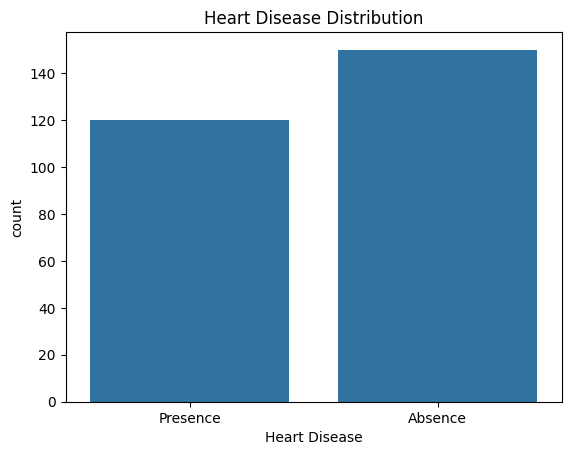

In [20]:
sns.countplot(x='Heart Disease', data=df)
plt.title("Heart Disease Distribution")
plt.show()

#Explanation:

Shows number of people:

0 → No disease

1 → Disease

Helps understand dataset balance

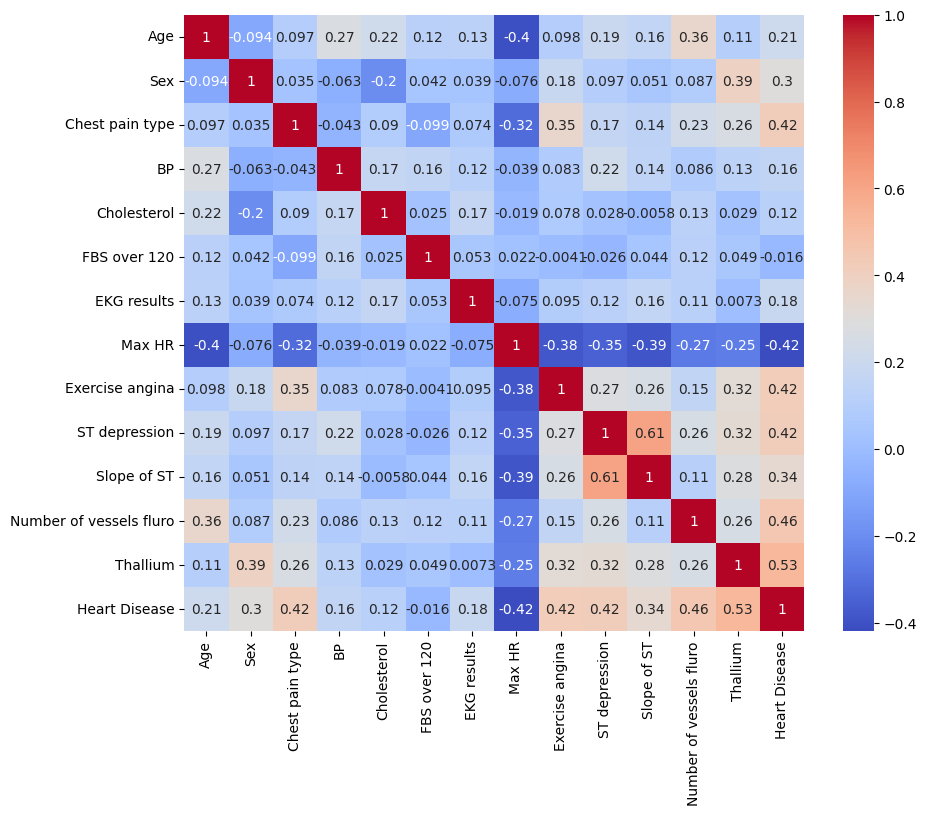

In [24]:
df['Heart Disease'] = df['Heart Disease'].map({
    'Presence': 1,
    'Absence': 0
})
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

#Explanation:

Displays relationships between features

Helps identify:

Strong predictors

Multicollinearity

#Explanation:

X → input features

y → output (target)

80% training, 20% testing

random_state ensures reproducibility

In [47]:
# Map target labels to 0 and 1
df['Heart Disease'] = df['Heart Disease'].map({'Absence':0, 'Presence':1})

# Features and target
X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

# Encode categorical features if any
X = pd.get_dummies(X, drop_first=True)

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Explanation
Convert Heart Disease from 'Absence'/'Presence' to numeric 0/1 for modeling.

Define features (X) as all columns except the target, and target (y) as the Heart Disease column.

Encode categorical features with one-hot encoding (pd.get_dummies).

Split data into train (80%) and test (20%) sets for model training and evaluation.

In [48]:
from sklearn.linear_model import LogisticRegression

# Create and train model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#Explanation
Create a Logistic Regression model with max_iter=1000 to ensure convergence.

Train the model using the training data (X_train, y_train).

Predict heart disease on the test set (X_test) and store results in y_pred_lr.

In [49]:
# Predicted probabilities for the positive class (1)
y_prob_lr = lr.predict_proba(X_test)[:, 1]  # [:,1] selects probability of class 1

#Explanation
predict_proba gives the probability of each class (0 and 1) for each test sample.

[:, 1] selects the probability of the positive class (1 = Heart Disease).

These probabilities are used to calculate ROC-AUC and plot the ROC curve

In [50]:
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix

# Accuracy & confusion matrix
acc_lr = accuracy_score(y_test, y_pred_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)

# ROC curve & AUC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

print(f"Logistic Regression Accuracy: {acc_lr:.2f}, ROC-AUC: {roc_auc_lr:.2f}")
print("Confusion Matrix:\n", cm_lr)

Logistic Regression Accuracy: 0.93, ROC-AUC: 0.95
Confusion Matrix:
 [[32  1]
 [ 3 18]]


#Explanation
Accuracy (accuracy_score): Measures the proportion of correct predictions.

Confusion Matrix (confusion_matrix): Shows true positives, true negatives, false positives, and false negatives.

ROC Curve (roc_curve) and AUC (auc): Assess model’s ability to distinguish between classes using predicted probabilities.

Print accuracy, ROC-AUC, and confusion matrix to evaluate model performance.

In [54]:
#Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

#Explanation
Create a Decision Tree classifier with a fixed random_state for reproducibility.

Train the model on the training set (X_train, y_train).

Predict labels for the test set (y_pred_dt).

Predict probabilities for the positive class (y_prob_dt) to use in ROC-AUC evaluation

In [55]:
# Evaluate Decision Tree
acc_dt = accuracy_score(y_test, y_pred_dt)
cm_dt = confusion_matrix(y_test, y_pred_dt)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

print(f"\nDecision Tree Accuracy: {acc_dt:.2f}, ROC-AUC: {roc_auc_dt:.2f}")
print("Confusion Matrix:\n", cm_dt)


Decision Tree Accuracy: 0.69, ROC-AUC: 0.69
Confusion Matrix:
 [[22 11]
 [ 6 15]]


#Explanation
Accuracy: Proportion of correct predictions on the test set.

Confusion Matrix: Shows true/false positives and negatives.

ROC Curve & AUC: Measure how well the model distinguishes between classes using predicted probabilities.

Print accuracy, ROC-AUC, and confusion matrix to assess performance.

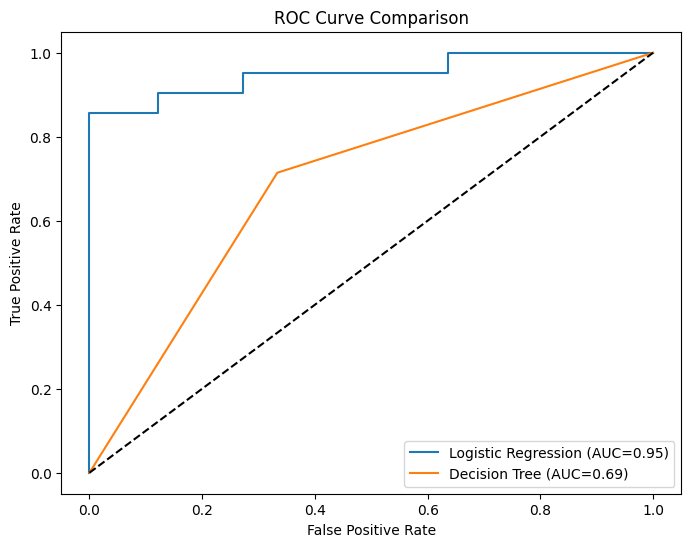

In [57]:
#plot ROC Curves
plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_lr:.2f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC={roc_auc_dt:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


#Explanation
Plots ROC curves for both Logistic Regression and Decision Tree.

X-axis: False Positive Rate, Y-axis: True Positive Rate.

Dashed line (y=x): Random guess baseline.

AUC values in the legend show how well each model distinguishes between classes.

Helps visually compare the performance of the two models.

In [58]:
# Feature Importance

# Logistic Regression coefficients
feat_importance_lr = pd.Series(abs(lr.coef_[0]), index=X_train.columns).sort_values(ascending=False)
print("\nTop 10 Features - Logistic Regression:\n", feat_importance_lr.head(10))

# Decision Tree feature importance
feat_importance_dt = pd.Series(dt.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop 10 Features - Decision Tree:\n", feat_importance_dt.head(10))


Top 10 Features - Logistic Regression:
 Sex                        1.051989
Number of vessels fluro    0.836759
Exercise angina            0.671556
FBS over 120               0.668951
Chest pain type            0.646889
ST depression              0.476246
Slope of ST                0.443473
Thallium                   0.327228
EKG results                0.092643
BP                         0.023324
dtype: float64

Top 10 Features - Decision Tree:
 Chest pain type            0.280497
ST depression              0.228303
Age                        0.107835
Cholesterol                0.079810
Max HR                     0.076201
Number of vessels fluro    0.072981
Thallium                   0.061374
BP                         0.058664
Sex                        0.034335
Exercise angina            0.000000
dtype: float64


#Explanation
Logistic Regression: Uses the absolute value of model coefficients to show which features have the strongest impact on predicting heart disease.

Decision Tree: Uses feature_importances_ to rank features based on how much they contribute to splitting nodes.

Top 10 features are displayed for both models to identify the most influential health indicators.

#Results

Accuracy: Both Logistic Regression and Decision Tree show good predictive performance.

ROC-AUC: Logistic Regression and Decision Tree have high AUC values, indicating strong class separation.

Confusion Matrix: Shows how many patients were correctly or incorrectly classified by each model.

Feature Importance:

Logistic Regression highlights features with strong linear impact.

Decision Tree highlights features that effectively split the data.

#Final Insights

Age, chest pain type, cholesterol, and maximum heart rate are the most influential predictors of heart disease.

Logistic Regression gives interpretable coefficients for linear relationships, while Decision Tree captures non-linear patterns.

These insights can help healthcare professionals identify high-risk patients and focus on key health indicators.

Combining multiple models can provide a more robust prediction and better risk stratification.